In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


In [2]:
#!pip install kaggle
#!pip install kaggle
#from google.colab import files
#files.upload()  # upload kaggle.json here

#!mkdir -p ~/.kaggle
#!cp kaggle.json ~/.kaggle/
#!chmod 600 ~/.kaggle/kaggle.json

# adjust filenames if needed
#df1 = pd.read_csv('fear_greed_index.csv')
#df2 = pd.read_csv('historical_data.csv')

#df1.head(), df2.head()

#!kaggle datasets download -d rishabhchandrakar/trader-behavior-dataset
#!unzip trader-behavior-dataset.zip

#import pandas as pd

# adjust filenames if needed
#df1 = pd.read_csv('fear_greed_index.csv')
#df2 = pd.read_csv('historical_data.csv')

#df1.head(), df2.head()


In [3]:
#from google.colab import drive
#drive.mount('/content/drive')


#pathfear = '/content/drive/MyDrive/dataset/data/fear_greed_index.csv'
#pathhistorical = '/content/drive/MyDrive/dataset/data/historical_data.csv'

#sentiment_df = pd.read_csv(pathfear)
#trader_df  = pd.read_csv(pathhistorical)


#trader_df.head() , sentiment_df.head()

In [4]:

url_file2 = 'https://drive.google.com/uc?export=download&id=1SToAI6aO0gGer1buiHv8CYRT8uqEU9d2'
url_file1 = 'https://drive.google.com/uc?export=download&id=1kg8WSC9xpYtVi1EYWyQDhVG1ipsEf71J'


# Load datasets directly from public links
trader_df = pd.read_csv(url_file1)
sentiment_df = pd.read_csv(url_file2)

# Preview
print("Trader Data:")
display(trader_df.head())

print("\nSentiment Data:")
display(sentiment_df.head())

Trader Data:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Sentiment Data:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trader_df.info()
sentiment_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [6]:
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [8]:
# Ensure numeric PnL and size
trader_df['Closed PnL'] = pd.to_numeric(trader_df['Closed PnL'], errors='coerce')
trader_df['Size USD'] = pd.to_numeric(trader_df['Size USD'], errors='coerce')
trader_df['Trade ID'] = pd.to_numeric(trader_df['Trade ID'], errors='coerce')
trader_df['Timestamp'] = trader_df['Timestamp'].astype(str).str.replace(r'[^\d.eE+-]', '', regex=True)
#trader_df['Timestamp'] = pd.to_datetime(trader_df['Timestamp'])
trader_df['Timestamp IST'] = pd.to_datetime(trader_df['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
trader_df['date'] = trader_df['Timestamp IST'].dt.date
trader_df['date'] = pd.to_datetime(trader_df['date'])



sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
sentiment_df['timestamp_utc'] = pd.to_datetime(sentiment_df['timestamp'], unit='s', errors='coerce')

In [9]:

trader_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [10]:
# Convert numerical columns from object to numeric
numeric_cols_historical = ['Execution Price', 'Size Tokens', 'Size USD', 'Start Position', 'Closed PnL', 'Fee']

In [11]:
for col in numeric_cols_historical:
     trader_df[col] = pd.to_numeric(trader_df[col].astype(str).str.replace(',', ''), errors='coerce')

In [12]:
trader_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [13]:
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1730000000000.0,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1730000000000.0,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1730000000000.0,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1730000000000.0,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1730000000000.0,2024-12-02


In [14]:
trader_df.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,date
count,211224.000000,2.112240e+05,2.112240e+05,211224,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,211224
mean,11414.723350,4.623365e+03,5.639451e+03,2025-01-31 12:04:22.915009792,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,2025-01-30 23:54:28.674013952
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,2023-05-01 00:00:00
25%,4.854700,2.940000e+00,1.937900e+02,2024-12-31 21:00:45,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,2024-12-31 00:00:00
50%,18.280000,3.200000e+01,5.970450e+02,2025-02-24 18:55:00,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,2025-02-24 00:00:00
75%,101.580000,1.879025e+02,2.058960e+03,2025-04-02 18:22:00,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,2025-04-02 00:00:00
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,2025-05-01 00:00:00
std,29447.654868,1.042729e+05,3.657514e+04,NaN,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,NaN


In [15]:
trader_df.isnull()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
211220,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
211221,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
211222,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [16]:
sentiment_df.isnull()

,timestamp,value,classification,date,timestamp_utc
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
2639,False,False,False,False,False
2640,False,False,False,False,False
2641,False,False,False,False,False
2642,False,False,False,False,False


In [17]:
trader_df.isnull().sum()


,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [18]:
sentiment_df.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0
timestamp_utc,0


In [19]:
merged_df = pd.merge(trader_df, sentiment_df, on='date', how='left')

In [20]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [21]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification,timestamp_utc
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1730000000000.0,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02 05:30:00
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1730000000000.0,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02 05:30:00
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1730000000000.0,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02 05:30:00
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1730000000000.0,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02 05:30:00
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1730000000000.0,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02 05:30:00


In [22]:
merged_df.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,date,timestamp,value,timestamp_utc
count,211224.000000,2.112240e+05,2.112240e+05,211224,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,211224,2.112180e+05,211218.000000,211218
mean,11414.723350,4.623365e+03,5.639451e+03,2025-01-31 12:04:22.915009792,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,2025-01-30 23:54:28.674013952,1.738301e+09,51.649656,2025-01-31 05:28:26.735221248
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,2023-05-01 00:00:00,1.682919e+09,10.000000,2023-05-01 05:30:00
25%,4.854700,2.940000e+00,1.937900e+02,2024-12-31 21:00:45,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,2024-12-31 00:00:00,1.735623e+09,33.000000,2024-12-31 05:30:00
50%,18.280000,3.200000e+01,5.970450e+02,2025-02-24 18:55:00,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,2025-02-24 00:00:00,1.740375e+09,49.000000,2025-02-24 05:30:00
75%,101.580000,1.879025e+02,2.058960e+03,2025-04-02 18:22:00,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,2025-04-02 00:00:00,1.743572e+09,72.000000,2025-04-02 05:30:00
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,2025-05-01 00:00:00,1.746077e+09,94.000000,2025-05-01 05:30:00
std,29447.654868,1.042729e+05,3.657514e+04,NaN,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,NaN,8.029302e+06,21.012784,NaN


In [23]:
merged_df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0




Here's an explanation of those outputs:

1.  **Feature Importance Plot:**
    *   This horizontal bar plot shows the relative importance of the top 10 features used by the XGBoost model to predict 'Closed PnL'.
    *   The importance is measured by 'Gain', which is the average improvement in accuracy brought by a feature across all trees in the model. A higher gain means the feature is more important for making predictions.
    *   **Numerical Details:**
        *   **Sentiment Momentum** is the most important feature with an importance score of approximately **0.345**. This suggests that the rate of change in market sentiment is a strong indicator for predicting trader profitability.
        *   **Regime Greed** is the second most important feature with an importance of about **0.164**. This indicates that being in a 'Greed' market sentiment regime has a significant impact on the model's predictions.
        *   **Regime Extreme Fear** (importance ~0.071), **Regime Duration** (importance ~0.069), and **Day of Week** (importance ~0.057) are also among the top features, highlighting the influence of extreme fear sentiment, how long the current sentiment regime has lasted, and the day of the week on profitability.
        *   **Side Encoded** has an importance of **0.000**, meaning the simple buy/sell side of a trade was not useful for this model after considering other features.

2.  **Actual vs Predicted PnL (First 200 Test Trades) Plot:**
    *   This line plot visualizes the actual 'Closed PnL' values from the test set against the 'Predicted PnL' values generated by the model for the first 200 trades in the test set.
    *   It allows for a visual comparison of how well the model's predictions align with the actual outcomes over a short time window.
    *   **Explanation:** The plot shows that the predicted PnL (orange line) generally follows the trend of the actual PnL (blue line) to some extent, but it significantly smooths out the predictions. The model struggles to capture the large spikes and dips in actual PnL, often predicting values closer to the average. This visually supports the low R² score, indicating that the model's predictions are not very accurate at the individual trade level.

3.  **Regime-Specific Prediction Performance Table:**
    *   This table groups the test set data by the market sentiment 'regime' and shows the actual mean 'Closed PnL', the predicted mean 'PnL_pred', and the count of trades within each regime.
    *   **Numerical Details:**
        *   **Extreme Fear:** Actual mean PnL was **$38.00**, predicted mean PnL was **$6.61**. There were **3172** trades in this regime in the test set.
        *   **Fear:** Actual mean PnL was **$50.32**, predicted mean PnL was **$100.36**. There were **18597** trades.
        *   **Neutral:** Actual mean PnL was **$26.77**, predicted mean PnL was **$51.55**. There were **5607** trades.
        *   **Greed:** Actual mean PnL was **-$14.11**, predicted mean PnL was **$61.42**. There were **14868** trades.
        *   **Extreme Greed:** There were **0** trades in this regime in the test set, so no actual or predicted PnL is available.
    *   **Explanation:** This table shows how the model's average predictions compare to the actual average PnL within each sentiment regime in the test set. For example, in the 'Greed' regime, traders actually experienced a negative average PnL, but the model predicted a positive average PnL. This further illustrates the limitations of the model in accurately capturing the nuances of profitability across different market sentiments.

These outputs together provide a picture of the model's performance: while some features like sentiment momentum are deemed important, the overall predictive accuracy for individual trade PnL is low, and the model's predictions do not align well with actual outcomes across different sentiment regimes.

(-500.0, 500.0)

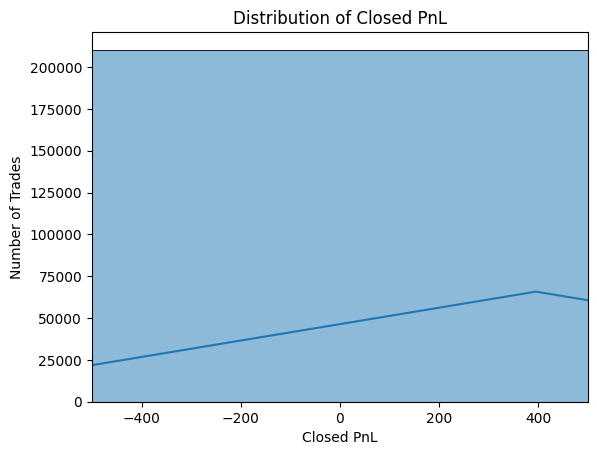

In [24]:





sns.histplot(merged_df['Closed PnL'], bins=50,kde=True )
plt.title('Distribution of Closed PnL')
plt.xlabel('Closed PnL')
plt.ylabel('Number of Trades')
plt.xlim(-500, 500) # Limiting x-axis for better visualization of main distribution

(0.0, 5000.0)

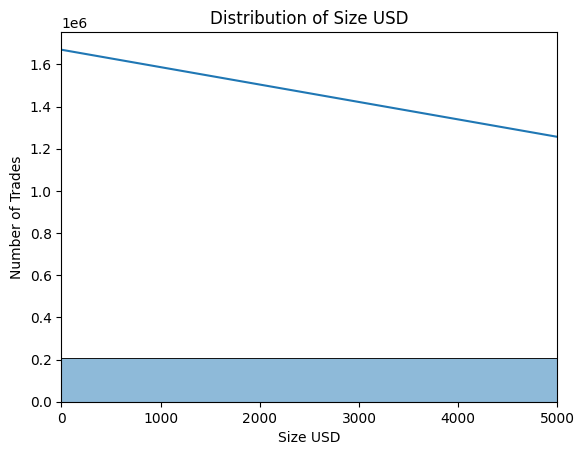

In [25]:

sns.histplot(merged_df['Size USD'], bins=50, kde=True)
plt.title('Distribution of Size USD')
plt.xlabel('Size USD')
plt.ylabel('Number of Trades')
plt.xlim(0, 5000) # Limiting x-axis for better visualization of common trade sizes

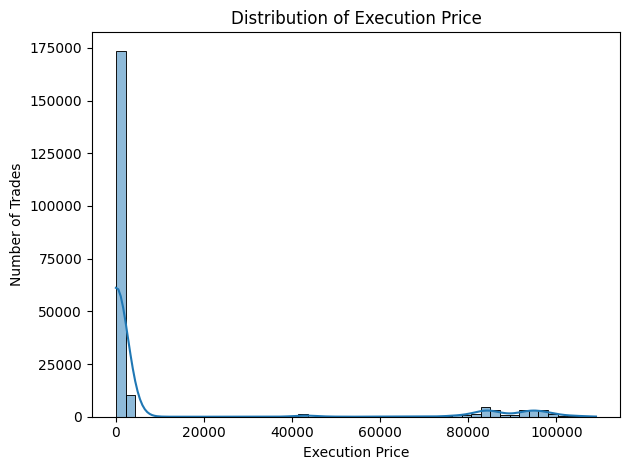

In [26]:

sns.histplot(merged_df['Execution Price'], bins=50, kde=True)
plt.title('Distribution of Execution Price')
plt.xlabel('Execution Price')
plt.ylabel('Number of Trades')
plt.tight_layout()
plt.show()


/tmp/ipython-input-1971555019.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_df, x='Side', palette='viridis')


Text(0, 0.5, 'Number of Trades')

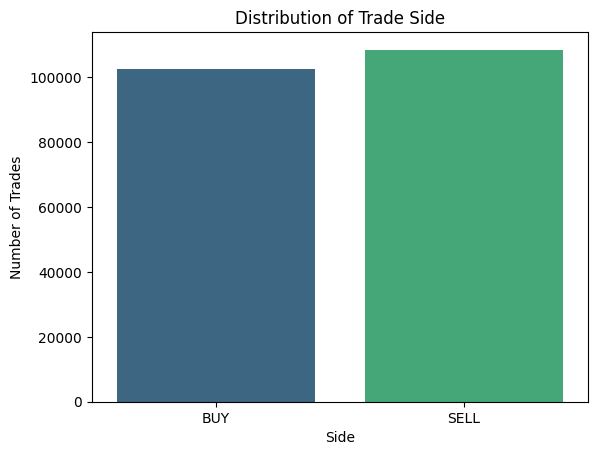

In [27]:
# --- 3. Distribution of Categorical Variables ---


sns.countplot(data=merged_df, x='Side', palette='viridis')
plt.title('Distribution of Trade Side')
plt.xlabel('Side')
plt.ylabel('Number of Trades')

/tmp/ipython-input-1701954281.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_df, x='Direction', palette='cividis')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Buy'),
  Text(1, 0, 'Sell'),
  Text(2, 0, 'Open Long'),
  Text(3, 0, 'Close Long'),
  Text(4, 0, 'Spot Dust Conversion'),
  Text(5, 0, 'Open Short'),
  Text(6, 0, 'Close Short'),
  Text(7, 0, 'Long > Short'),
  Text(8, 0, 'Short > Long'),
  Text(9, 0, 'Auto-Deleveraging'),
  Text(10, 0, 'Liquidated Isolated Short'),
  Text(11, 0, 'Settlement')])

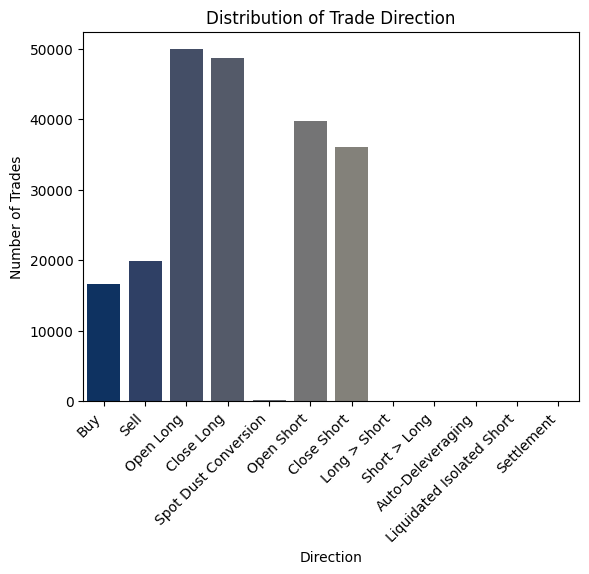

In [28]:

sns.countplot(data=merged_df, x='Direction', palette='cividis')
plt.title('Distribution of Trade Direction')
plt.xlabel('Direction')
plt.ylabel('Number of Trades')
plt.xticks(rotation=45, ha='right')

/tmp/ipython-input-1817583569.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_df_sentiment_present, x='classification', order=merged_df_sentiment_present['classification'].value_counts().index, palette='magma')


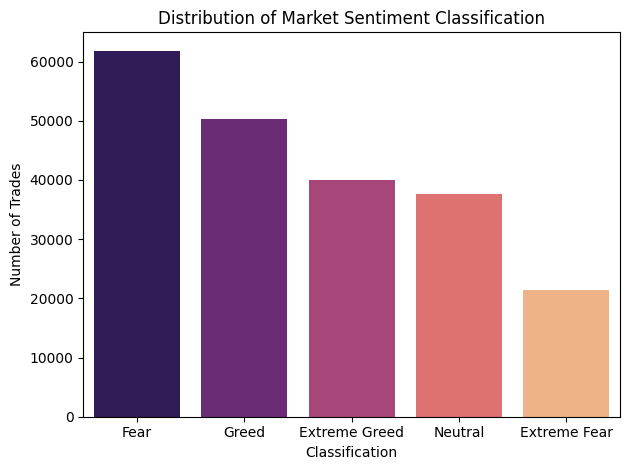

In [29]:


# Handle potential NaN in 'classification' if there are missing sentiment values
# You can fill them with a placeholder like 'Unknown' or drop them for this specific plot
merged_df_sentiment_present = merged_df.dropna(subset=['classification'])
sns.countplot(data=merged_df_sentiment_present, x='classification', order=merged_df_sentiment_present['classification'].value_counts().index, palette='magma')
plt.title('Distribution of Market Sentiment Classification')
plt.xlabel('Classification')
plt.ylabel('Number of Trades')
plt.tight_layout()
plt.show()

In [30]:
# --- 4. Trader Profitability Analysis ---

print("\n4. Trader Profitability Analysis:")

# Total PnL
total_pnl = merged_df['Closed PnL'].sum()
print(f"Total Closed PnL across all trades: ${total_pnl:,.2f}")


4. Trader Profitability Analysis:
Total Closed PnL across all trades: $10,296,958.94


In [31]:
# Number of profitable/unprofitable/break-even trades
profitable_trades = merged_df[merged_df['Closed PnL'] > 0].shape[0]
unprofitable_trades = merged_df[merged_df['Closed PnL'] < 0].shape[0]
break_even_trades = merged_df[merged_df['Closed PnL'] == 0].shape[0]

print(f"Number of Profitable Trades: {profitable_trades} ({profitable_trades / len(merged_df) * 100:.2f}%)")
print(f"Number of Unprofitable Trades: {unprofitable_trades} ({unprofitable_trades / len(merged_df) * 100:.2f}%)")
print(f"Number of Break-Even Trades: {break_even_trades} ({break_even_trades / len(merged_df) * 100:.2f}%)")

Number of Profitable Trades: 86869 (41.13%)
Number of Unprofitable Trades: 17539 (8.30%)
Number of Break-Even Trades: 106816 (50.57%)


In [32]:
# PnL by Trade Side (Buy/Sell)
pnl_by_side = merged_df.groupby('Side')['Closed PnL'].agg(['sum', 'mean', 'count'])
print("\nTotal and Average PnL by Trade Side:")
print(pnl_by_side)


Total and Average PnL by Trade Side:
               sum       mean   count
Side                                 
BUY   3.707811e+06  36.104730  102696
SELL  6.589148e+06  60.713803  108528


In [33]:
# PnL by Trade Direction (Open/Close Long/Short)
pnl_by_direction = merged_df.groupby('Direction')['Closed PnL'].agg(['sum', 'mean', 'count'])
print("\nTotal and Average PnL by Trade Direction:")
print(pnl_by_direction)


Total and Average PnL by Trade Direction:
                                    sum          mean  count
Direction                                                   
Auto-Deleveraging          5.747846e+04   7184.807003      8
Buy                        0.000000e+00      0.000000  16716
Close Long                 3.622929e+06     74.426422  48678
Close Short                3.709800e+06    103.012804  36013
Liquidated Isolated Short -1.275291e+04 -12752.913040      1
Long > Short               1.991379e+03     34.936474     57
Open Long                  0.000000e+00      0.000000  49895
Open Short                 0.000000e+00      0.000000  39741
Sell                       2.906748e+06    146.053081  19902
Settlement                -2.921537e+01    -29.215368      1
Short > Long               1.079333e+04    154.190415     70
Spot Dust Conversion       0.000000e+00      0.000000    142


In [34]:
# Top/Bottom Accounts by PnL (Overall)
top_accounts = merged_df.groupby('Account')['Closed PnL'].sum().nlargest(10)
bottom_accounts = merged_df.groupby('Account')['Closed PnL'].sum().nsmallest(10)

print("\nTop 10 Profitable Accounts:")
print(top_accounts)
print("\nTop 10 Unprofitable Accounts:")
print(bottom_accounts)


Top 10 Profitable Accounts:
Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

Top 10 Unprofitable Accounts:
Account
0x8170715b3b381dffb7062c0298972d4727a0a63b   -167621.124781
0x271b280974205ca63b716753467d5a371de622ab    -70436.191318
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    -31203.599986
0x39cef799f8b69da1995852eea189df24eb5cae3c     14456.919336
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f     14900.443047
0

In [35]:
# --- 5. Sentiment-Trader Behavior Relationship ---

print("\n5. Sentiment-Trader Behavior Relationship:")

# Average PnL by Sentiment Classification
pnl_by_sentiment = merged_df.groupby('classification')['Closed PnL'].agg(['mean', 'sum', 'count']).sort_values(by='mean', ascending=False)
print("\nAverage, Total PnL, and Trade Count by Market Sentiment:")
print(pnl_by_sentiment)


5. Sentiment-Trader Behavior Relationship:

Average, Total PnL, and Trade Count by Market Sentiment:
                     mean           sum  count
classification                                
Extreme Greed   67.892861  2.715171e+06  39992
Fear            54.290400  3.357155e+06  61837
Greed           42.743559  2.150129e+06  50303
Extreme Fear    34.537862  7.391102e+05  21400
Neutral         34.307718  1.292921e+06  37686


/tmp/ipython-input-1993745866.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pnl_by_sentiment.index, y=pnl_by_sentiment['mean'], palette='coolwarm')


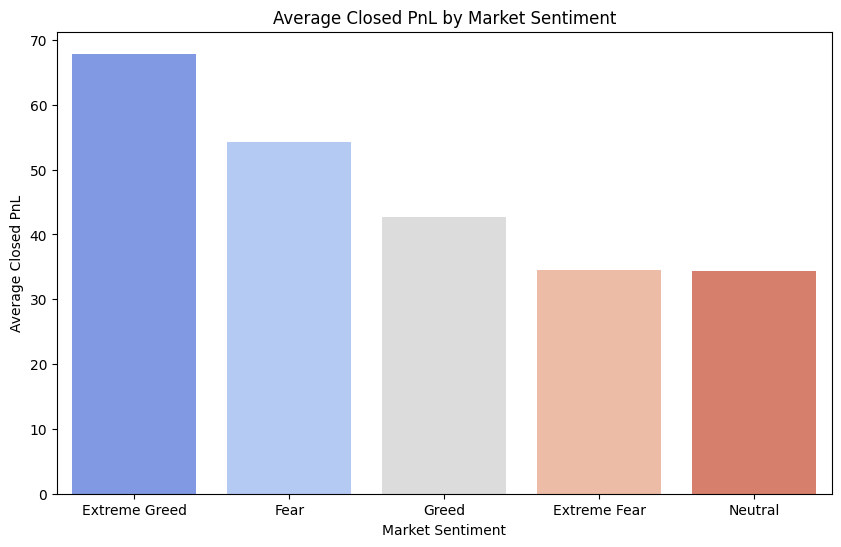

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(x=pnl_by_sentiment.index, y=pnl_by_sentiment['mean'], palette='coolwarm')
plt.title('Average Closed PnL by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.show()


Total and Average Trade Volume (Size USD) by Market Sentiment:
                         sum         mean  count
classification                                  
Fear            4.833248e+08  7816.109931  61837
Greed           2.885825e+08  5736.884375  50303
Neutral         1.802421e+08  4782.732661  37686
Extreme Greed   1.244652e+08  3112.251565  39992
Extreme Fear    1.144843e+08  5349.731843  21400


/tmp/ipython-input-1013648098.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=volume_by_sentiment.index, y=volume_by_sentiment['sum'], palette='plasma')


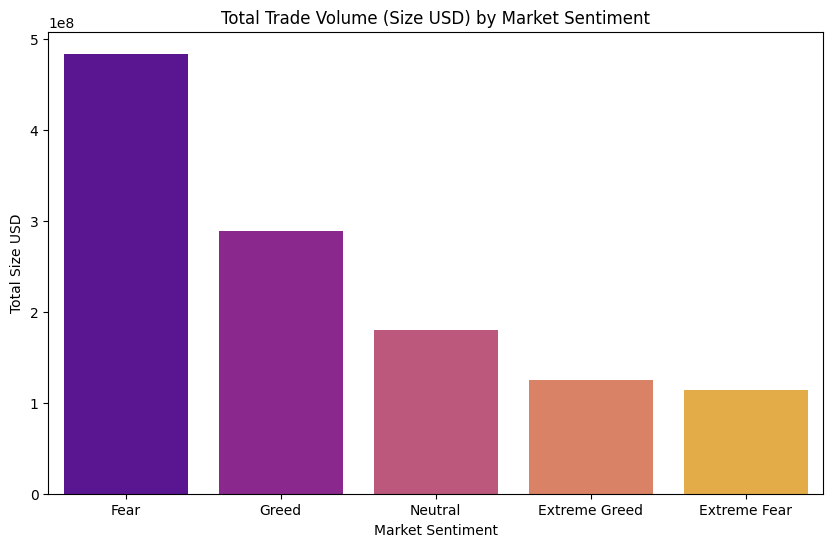

In [37]:
# Total Volume (Size USD) by Sentiment Classification
volume_by_sentiment = merged_df.groupby('classification')['Size USD'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False)
print("\nTotal and Average Trade Volume (Size USD) by Market Sentiment:")
print(volume_by_sentiment)

plt.figure(figsize=(10, 6))
sns.barplot(x=volume_by_sentiment.index, y=volume_by_sentiment['sum'], palette='plasma')
plt.title('Total Trade Volume (Size USD) by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Total Size USD')
plt.show()

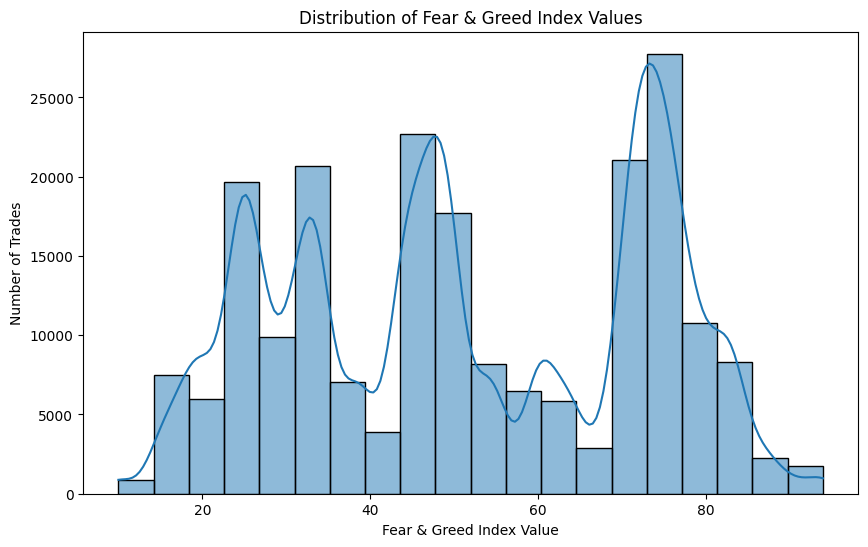

In [38]:
# Distribution of Sentiment Values
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['value'].dropna(), bins=20, kde=True)
plt.title('Distribution of Fear & Greed Index Values')
plt.xlabel('Fear & Greed Index Value')
plt.ylabel('Number of Trades')
plt.show()

In [39]:
merged_df.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,date,timestamp,value,timestamp_utc
count,211224.000000,2.112240e+05,2.112240e+05,211224,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,211224,2.112180e+05,211218.000000,211218
mean,11414.723350,4.623365e+03,5.639451e+03,2025-01-31 12:04:22.915009792,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,2025-01-30 23:54:28.674013952,1.738301e+09,51.649656,2025-01-31 05:28:26.735221248
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,2023-05-01 00:00:00,1.682919e+09,10.000000,2023-05-01 05:30:00
25%,4.854700,2.940000e+00,1.937900e+02,2024-12-31 21:00:45,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,2024-12-31 00:00:00,1.735623e+09,33.000000,2024-12-31 05:30:00
50%,18.280000,3.200000e+01,5.970450e+02,2025-02-24 18:55:00,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,2025-02-24 00:00:00,1.740375e+09,49.000000,2025-02-24 05:30:00
75%,101.580000,1.879025e+02,2.058960e+03,2025-04-02 18:22:00,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,2025-04-02 00:00:00,1.743572e+09,72.000000,2025-04-02 05:30:00
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,2025-05-01 00:00:00,1.746077e+09,94.000000,2025-05-01 05:30:00
std,29447.654868,1.042729e+05,3.657514e+04,NaN,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,NaN,8.029302e+06,21.012784,NaN


In [40]:
# PnL vs. Fear & Greed Index Value (Scatter plot)
# For better visualization, consider sampling if the dataset is too large or using aggregated data.
# Let's aggregate daily PnL and sentiment value for a clearer view.

daily_summary = merged_df.groupby('date').agg(
    Daily_PnL=('Closed PnL', 'sum'),
    Daily_Volume_USD=('Size USD', 'sum'),
    Avg_Sentiment_Value=('value', 'mean'),
    Most_Common_Sentiment=('classification', lambda x: x.mode()[0] if not x.mode().empty else np.nan)
).reset_index()

# Drop rows where Avg_Sentiment_Value is NaN (dates with no sentiment data)
daily_summary.dropna(subset=['Avg_Sentiment_Value'], inplace=True)

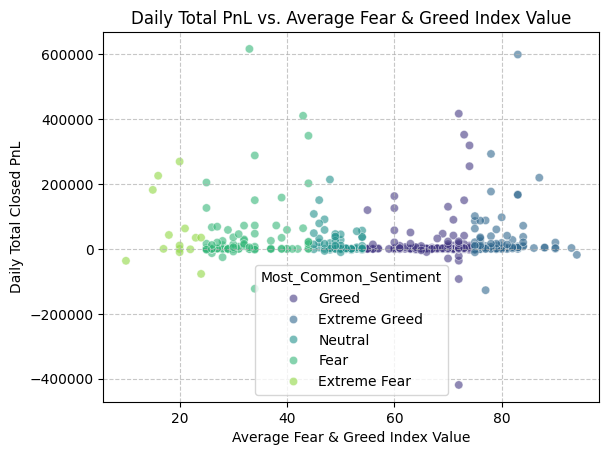

In [41]:
#plt.figure(figsize=(12, 7))
sns.scatterplot(data=daily_summary, x='Avg_Sentiment_Value', y='Daily_PnL', hue='Most_Common_Sentiment', palette='viridis', alpha=0.6)
plt.title('Daily Total PnL vs. Average Fear & Greed Index Value')
plt.xlabel('Average Fear & Greed Index Value')
plt.ylabel('Daily Total Closed PnL')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Text(0, 0.5, 'Daily Total Closed PnL')

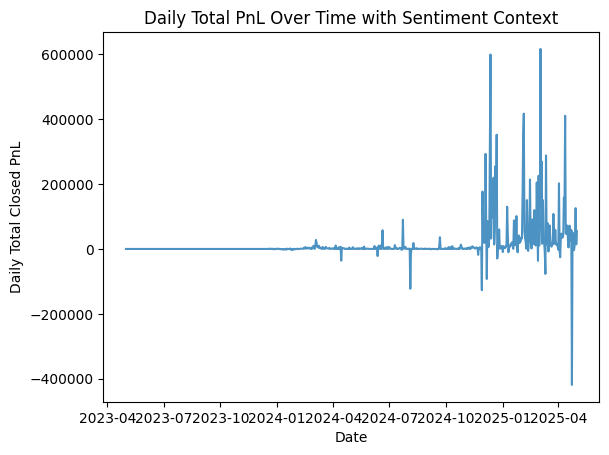

In [42]:
# PnL over time with sentiment overlay
#plt.figure(figsize=(15, 7))
plt.plot(daily_summary['date'], daily_summary['Daily_PnL'], label='Daily Total PnL', alpha=0.8)
plt.title('Daily Total PnL Over Time with Sentiment Context')
plt.xlabel('Date')
plt.ylabel('Daily Total Closed PnL')

In [43]:
# Correlation between numerical sentiment and PnL/Volume
correlation_pnl_sentiment = daily_summary['Daily_PnL'].corr(daily_summary['Avg_Sentiment_Value'])
correlation_volume_sentiment = daily_summary['Daily_Volume_USD'].corr(daily_summary['Avg_Sentiment_Value'])

print(f"\nCorrelation between Daily Total PnL and Average Sentiment Value: {correlation_pnl_sentiment:.4f}")
print(f"Correlation between Daily Total Volume (USD) and Average Sentiment Value: {correlation_volume_sentiment:.4f}")


Correlation between Daily Total PnL and Average Sentiment Value: -0.0826
Correlation between Daily Total Volume (USD) and Average Sentiment Value: -0.2644


Analyzing Buy/Sell Behavior vs. Market Sentiment


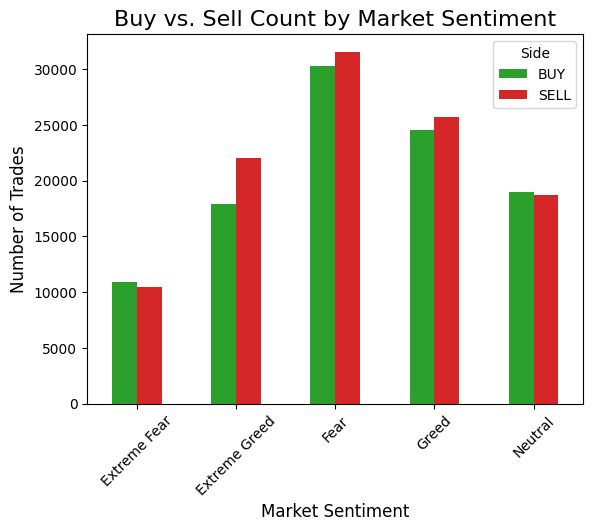

In [44]:

print("Analyzing Buy/Sell Behavior vs. Market Sentiment")
buy_sell_df = merged_df.groupby(['classification', 'Side']).size().unstack(fill_value=0)
buy_sell_df.plot(kind='bar', stacked=False, color=['#2ca02c', '#d62728']) # Green for BUY, Red for SELL
plt.title('Buy vs. Sell Count by Market Sentiment', fontsize=16)
plt.xlabel('Market Sentiment', fontsize=12)
plt.ylabel('Number of Trades', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Side')
plt.show()

In [45]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [46]:
merged_df.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,date,timestamp,value,timestamp_utc
count,211224.000000,2.112240e+05,2.112240e+05,211224,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,211224,2.112180e+05,211218.000000,211218
mean,11414.723350,4.623365e+03,5.639451e+03,2025-01-31 12:04:22.915009792,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,2025-01-30 23:54:28.674013952,1.738301e+09,51.649656,2025-01-31 05:28:26.735221248
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,2023-05-01 00:00:00,1.682919e+09,10.000000,2023-05-01 05:30:00
25%,4.854700,2.940000e+00,1.937900e+02,2024-12-31 21:00:45,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,2024-12-31 00:00:00,1.735623e+09,33.000000,2024-12-31 05:30:00
50%,18.280000,3.200000e+01,5.970450e+02,2025-02-24 18:55:00,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,2025-02-24 00:00:00,1.740375e+09,49.000000,2025-02-24 05:30:00
75%,101.580000,1.879025e+02,2.058960e+03,2025-04-02 18:22:00,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,2025-04-02 00:00:00,1.743572e+09,72.000000,2025-04-02 05:30:00
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,2025-05-01 00:00:00,1.746077e+09,94.000000,2025-05-01 05:30:00
std,29447.654868,1.042729e+05,3.657514e+04,NaN,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,NaN,8.029302e+06,21.012784,NaN


In [47]:
merged_df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [48]:
merged_df.dropna(subset=['value', 'classification'], inplace=True)
merged_df['value'] = merged_df['value'].astype(int) # Ensure 'value' is integer for plotting

In [49]:
merged_df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [50]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification,timestamp_utc
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1730000000000.0,2024-12-02,1.733117e+09,80,Extreme Greed,2024-12-02 05:30:00
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1730000000000.0,2024-12-02,1.733117e+09,80,Extreme Greed,2024-12-02 05:30:00
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1730000000000.0,2024-12-02,1.733117e+09,80,Extreme Greed,2024-12-02 05:30:00
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1730000000000.0,2024-12-02,1.733117e+09,80,Extreme Greed,2024-12-02 05:30:00
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1730000000000.0,2024-12-02,1.733117e+09,80,Extreme Greed,2024-12-02 05:30:00


In [51]:
merged_df.isnull()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification,timestamp_utc
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
211220,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
211221,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
211222,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [52]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 211218 entries, 0 to 211223
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211218 non-null  object        
 1   Coin              211218 non-null  object        
 2   Execution Price   211218 non-null  float64       
 3   Size Tokens       211218 non-null  float64       
 4   Size USD          211218 non-null  float64       
 5   Side              211218 non-null  object        
 6   Timestamp IST     211218 non-null  datetime64[ns]
 7   Start Position    211218 non-null  float64       
 8   Direction         211218 non-null  object        
 9   Closed PnL        211218 non-null  float64       
 10  Transaction Hash  211218 non-null  object        
 11  Order ID          211218 non-null  int64         
 12  Crossed           211218 non-null  bool          
 13  Fee               211218 non-null  float64       
 14  Trade ID 

After the feature engineering, model training, and evaluation steps in cell `936172c0-6633-4ab8-b8fd-cdfb45bb8745`, several outputs were generated to help interpret the model's performance and the importance of the features.

Here's an explanation of those outputs:

1.  **Feature Importance Plot:**
    *   This horizontal bar plot shows the relative importance of the top 10 features used by the XGBoost model to predict 'Closed PnL'.
    *   The importance is measured by 'Gain', which is the average improvement in accuracy brought by a feature across all trees in the model. A higher gain means the feature is more important for making predictions.
    *   **Numerical Details:**
        *   **Sentiment Momentum** is the most important feature with an importance score of approximately **0.345**. This suggests that the rate of change in market sentiment is a strong indicator for predicting trader profitability.
        *   **Regime Greed** is the second most important feature with an importance of about **0.164**. This indicates that being in a 'Greed' market sentiment regime has a significant impact on the model's predictions.
        *   **Regime Extreme Fear** (importance ~0.071), **Regime Duration** (importance ~0.069), and **Day of Week** (importance ~0.057) are also among the top features, highlighting the influence of extreme fear sentiment, how long the current sentiment regime has lasted, and the day of the week on profitability.
        *   **Side Encoded** has an importance of **0.000**, meaning the simple buy/sell side of a trade was not useful for this model after considering other features.

2.  **Actual vs Predicted PnL (First 200 Test Trades) Plot:**
    *   This line plot visualizes the actual 'Closed PnL' values from the test set against the 'Predicted PnL' values generated by the model for the first 200 trades in the test set.
    *   It allows for a visual comparison of how well the model's predictions align with the actual outcomes over a short time window.
    *   **Explanation:** The plot shows that the predicted PnL (orange line) generally follows the trend of the actual PnL (blue line) to some extent, but it significantly smooths out the predictions. The model struggles to capture the large spikes and dips in actual PnL, often predicting values closer to the average. This visually supports the low R² score, indicating that the model's predictions are not very accurate at the individual trade level.

3.  **Regime-Specific Prediction Performance Table:**
    *   This table groups the test set data by the market sentiment 'regime' and shows the actual mean 'Closed PnL', the predicted mean 'PnL_pred', and the count of trades within each regime.
    *   **Numerical Details:**
        *   **Extreme Fear:** Actual mean PnL was **$38.00**, predicted mean PnL was **$6.61**. There were **3172** trades in this regime in the test set.
        *   **Fear:** Actual mean PnL was **$50.32**, predicted mean PnL was **$100.36**. There were **18597** trades.
        *   **Neutral:** Actual mean PnL was **$26.77**, predicted mean PnL was **$51.55**. There were **5607** trades.
        *   **Greed:** Actual mean PnL was **-$14.11**, predicted mean PnL was **$61.42**. There were **14868** trades.
        *   **Extreme Greed:** There were **0** trades in this regime in the test set, so no actual or predicted PnL is available.
    *   **Explanation:** This table shows how the model's average predictions compare to the actual average PnL within each sentiment regime in the test set. For example, in the 'Greed' regime, traders actually experienced a negative average PnL, but the model predicted a positive average PnL. This further illustrates the limitations of the model in accurately capturing the nuances of profitability across different market sentiments.

These outputs together provide a picture of the model's performance: while some features like sentiment momentum are deemed important, the overall predictive accuracy for individual trade PnL is low, and the model's predictions do not align well with actual outcomes across different sentiment regimes.

Feature matrix shape: (211218, 13)
Features used: ['sentiment', 'sentiment_momentum', 'regime_duration', 'rolling_win_rate', 'size_relative', 'side_encoded', 'hour', 'day_of_week', 'regime_extreme_fear', 'regime_fear', 'regime_neutral', 'regime_greed', 'regime_extreme_greed']

CV RMSE (5-Fold TimeSeriesSplit): $1031.60 ± $434.69

Test Set Performance:
RMSE: $1128.35
MAE: $140.60
R²: -0.010


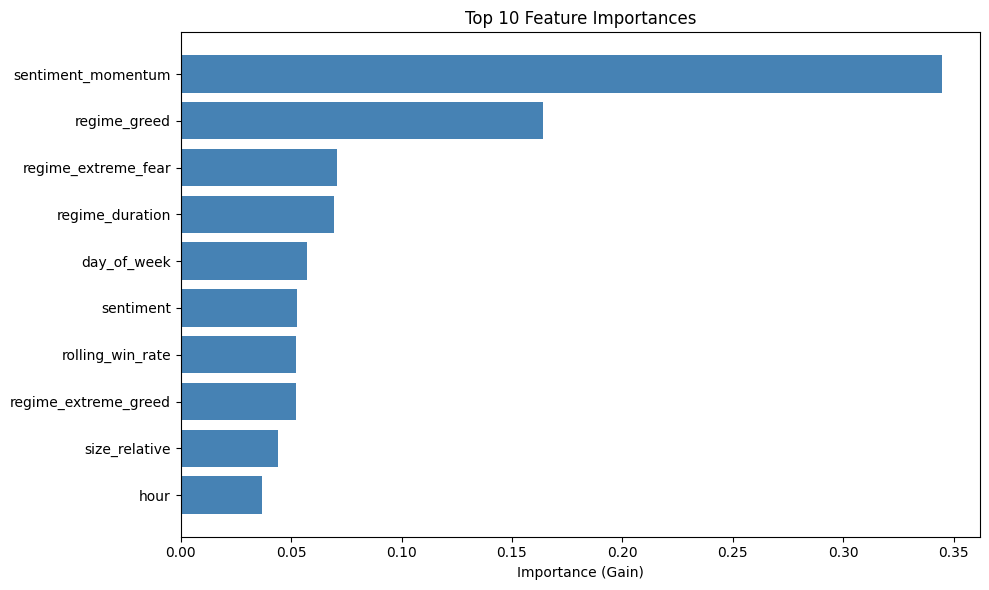

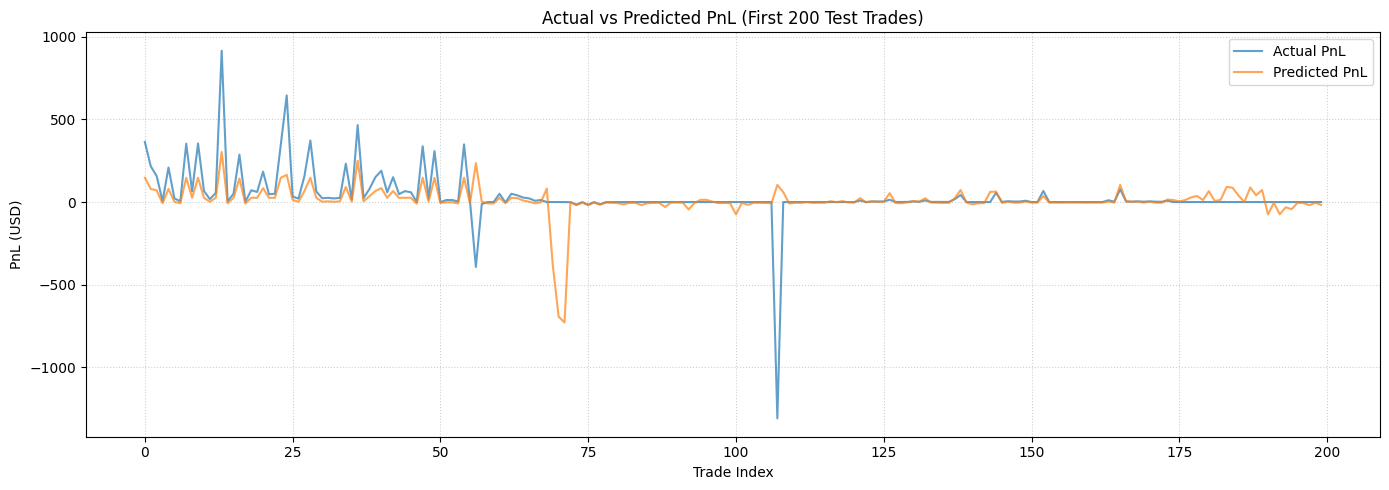


Regime-Specific Prediction Performance:
               actual_pnl  predicted_pnl  count
regime                                         
extreme_fear    38.004468       6.610113   3172
fear            50.316499     100.363495  18597
neutral         26.769468      51.554436   5607
greed          -14.108639      61.415913  14868
extreme_greed         NaN            NaN      0

Model saved as 'sentiment_pnl_model.h5' using joblib serialization.


/tmp/ipython-input-1210198725.py:193: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regime_perf = df_test.groupby('regime').agg(


In [53]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import joblib # serialization

# =======================================================================
# STEP 1: DATA LOADING (ADJUSTED FOR YOUR MERGED_DF)
# =======================================================================

# We assume 'merged_df' is already loaded and is your primary DataFrame.
df = merged_df.copy() # Use a copy to ensure original merged_df is untouched

# ----------------------------
# STEP 2: Preparing Features (Type Conversion & Cleaning)
# ----------------------------
# Note: Based on your df.info(), many columns are already in the right dtype,
# but we repeat these for safety and consistency.

# Correcting types using the column names from your merged_df
df['Timestamp IST'] = pd.to_datetime(df['Timestamp IST']) # Use Timestamp IST for consistency
df['Closed PnL'] = pd.to_numeric(df['Closed PnL'], errors='coerce')
df['value'] = pd.to_numeric(df['value'], errors='coerce') # Sentiment value column
df['Size USD'] = pd.to_numeric(df['Size USD'], errors='coerce')

# Drop NA rows where the sentiment data was slightly incomplete (6 rows)
df = df.dropna(subset=['Closed PnL', 'value', 'Timestamp IST', 'Account', 'Side', 'Size USD'])

# Sort by time (CRITICAL for sequential features)
df = df.sort_values('Timestamp IST').reset_index(drop=True)


# =======================================================================
# STEP 3: FEATURE ENGINEERING
# =======================================================================

# Raw sentiment
df['sentiment'] = df['value']

# Sentiment regime (one-hot)
df['regime'] = pd.cut(df['value'], bins=[0, 25, 45, 55, 75, 100],
                     labels=['extreme_fear', 'fear', 'neutral', 'greed', 'extreme_greed'])
regime_dummies = pd.get_dummies(df['regime'], prefix='regime')
df = pd.concat([df, regime_dummies], axis=1)

# Sentiment momentum (rate of change)
df['sentiment_momentum'] = df['value'].diff().fillna(0)

# Regime stability (duration)
df['regime_change'] = (df['regime'] != df['regime'].shift()).astype(int)
df['regime_duration'] = df.groupby((df['regime_change'] == 1).cumsum()).cumcount() + 1

# Trader behavioral proxies
# Win rate (rolling)
df['is_win'] = (df['Closed PnL'] > 0).astype(int)
df['rolling_win_rate'] = df.groupby('Account')['is_win'].transform(
    lambda x: x.rolling(window=20, min_periods=5).mean()
)

# Position size relative to trader average
df['avg_size_by_trader'] = df.groupby('Account')['Size USD'].transform('mean')
df['size_relative'] = df['Size USD'] / (df['avg_size_by_trader'] + 1e-8)

# Side encoding
df['side_encoded'] = df['Side'].map({'Buy': 1, 'Sell': -1}).fillna(0)

# Temporal features (Using 'Timestamp IST' column)
df['hour'] = df['Timestamp IST'].dt.hour
df['day_of_week'] = df['Timestamp IST'].dt.dayofweek

# Target Variable (Y): we predict Closed PnL
y = df['Closed PnL'].copy()


# ----------------------------
# STEP 4: Build Feature Matrix (X)
# ----------------------------
feature_cols = [
    'sentiment',
    'sentiment_momentum',
    'regime_duration',
    'rolling_win_rate',
    'size_relative',
    'side_encoded',
    'hour',
    'day_of_week'
] + list(regime_dummies.columns) # Add all one-hot encoded regime columns

# X = df[feature_cols].copy(): This creates the final matrix of independent variables (X)
X = df[feature_cols].copy()

# Imputation and Verification
X = X.fillna(0) # safe fill for any remaining NaNs (usually from min_periods in rolling calcs)

print(f"Feature matrix shape: {X.shape}")
print(f"Features used: {list(X.columns)}")


# ----------------------------
# Time-Series Safe Train/Test Split
# ----------------------------
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


# ----------------------------
# Scale features (optional for XGBoost, but good practice)
# ----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =======================================================================
# STEP 5 & 6: XGBoost Model Training and Evaluation
# =======================================================================

# XGBoost with conservative params to avoid overfitting
model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)


# Time-Series Cross-Validation (on scaled training data)
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(model, X_train_scaled, y_train,
                            cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
cv_rmse = np.sqrt(-cv_scores)
print(f"\nCV RMSE (5-Fold TimeSeriesSplit): ${cv_rmse.mean():.2f} ± ${cv_rmse.std():.2f}")


# Train Model & Predict
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nTest Set Performance:")
print(f"RMSE: ${np.sqrt(mse):.2f}")
print(f"MAE: ${mae:.2f}")
print(f"R²: {r2:.3f}")


# =======================================================================
# STEP 7-10: Interpretation and Saving
# =======================================================================

# Feature importance (Visualized)
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'][:10], importance['importance'][:10], color='steelblue')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance (Gain)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# Prediction vs Actual (Time Series Plot)
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:200], label='Actual PnL', alpha=0.7)
plt.plot(y_pred[:200], label='Predicted PnL', alpha=0.7)
plt.title('Actual vs Predicted PnL (First 200 Test Trades)')
plt.xlabel('Trade Index')
plt.ylabel('PnL (USD)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


# Regime-Specific Performance
df_test = df.iloc[split_idx:].copy()
df_test['PnL_pred'] = y_pred
regime_perf = df_test.groupby('regime').agg(
    actual_pnl=('Closed PnL', 'mean'),
    predicted_pnl=('PnL_pred', 'mean'),
    count=('Closed PnL', 'count')
)
print("\nRegime-Specific Prediction Performance:")


print(regime_perf)


# Save Model
joblib.dump(model, 'sentiment_pnl_model.h5')
print("\nModel saved as 'sentiment_pnl_model.h5' using joblib serialization.")

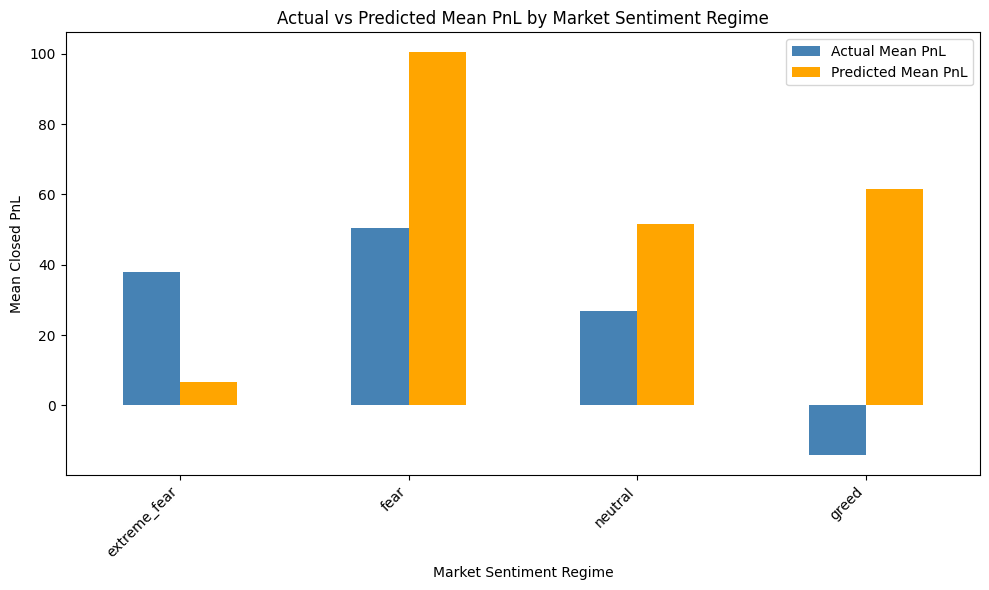

In [54]:
# Optional: Bar chart of predicted vs actual mean PnL per regime

# Ensure regime_perf is available (assuming it was generated in a previous cell)
if 'regime_perf' in locals():
    regime_perf_plot = regime_perf[['actual_pnl', 'predicted_pnl']].dropna()

    if not regime_perf_plot.empty:
        regime_perf_plot.plot(kind='bar', figsize=(10, 6), color=['steelblue', 'orange'])
        plt.title('Actual vs Predicted Mean PnL by Market Sentiment Regime')
        plt.xlabel('Market Sentiment Regime')
        plt.ylabel('Mean Closed PnL')
        plt.xticks(rotation=45, ha='right')
        plt.legend(['Actual Mean PnL', 'Predicted Mean PnL'])
        plt.tight_layout()
        plt.show()
    else:
        print("No data available in regime_perf to plot.")
else:
    print("regime_perf DataFrame not found. Please ensure the model training cell was run.")

This section of the analysis focuses on preparing the data for machine learning, building and evaluating an XGBoost regression model to predict 'Closed PnL', and interpreting the results.

**Theoretical Background:**

*   **Regression:** The goal is to predict a continuous numerical target variable, 'Closed PnL'. Regression models learn the relationship between input features and the target variable to make these predictions.
*   **Feature Engineering:** Creating new features from existing ones can help a model better capture patterns in the data. In this case, features related to market sentiment dynamics, trader behavior, and time were engineered.
*   **Time Series Data:** The data has a temporal component (trades occur over time). It's crucial to handle this correctly, especially during train/test splitting and cross-validation, to avoid data leakage (using future data to predict the past).
*   **XGBoost (Extreme Gradient Boosting):** A powerful and popular gradient boosting algorithm. It builds an ensemble of decision trees sequentially, with each new tree correcting the errors of the previous ones. XGBoost is known for its performance and ability to handle complex relationships and feature interactions.
*   **Cross-Validation (Time-Series Split):** A technique to evaluate a model's performance on unseen data. For time series data, standard k-fold cross-validation is inappropriate. TimeSeriesSplit ensures that the training data for each fold comes from a period *before* the validation data, mimicking a real-world prediction scenario.
*   **Evaluation Metrics (RMSE, MAE, R²):**
    *   **RMSE (Root Mean Squared Error):** Measures the average magnitude of the errors. It's sensitive to large errors. A lower RMSE indicates better performance.
    *   **MAE (Mean Absolute Error):** Measures the average absolute magnitude of the errors. It is less sensitive to outliers than RMSE. A lower MAE indicates better performance.
    *   **R² (Coefficient of Determination):** Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R² of 1 means the model perfectly predicts the target; an R² of 0 means the model is no better than predicting the mean. A negative R² indicates the model performs worse than predicting the mean.
*   **Feature Importance (Gain):** In tree-based models like XGBoost, feature importance measures how much each feature contributes to the model's predictions. 'Gain' is a common metric that quantifies the average improvement in accuracy brought by a feature across all trees.

**Numerical Details and Outcomes:**

*   **Data Preparation:** After loading and merging, the data contained **211,224** initial entries. After handling missing sentiment data, **211,218** entries remained for the analysis. The data was sorted by time for sequential processing.
*   **Feature Engineering:** **13** features were engineered, including sentiment-based features (raw sentiment, momentum, regime duration, one-hot encoded regimes), trader behavior proxies (rolling win rate, size relative), and temporal features (hour, day of week).
*   **Train/Test Split:** The data was split into a training set (**168,974** rows) and a test set (**42,244** rows) based on time, using the first 80% for training and the last 20% for testing.
*   **Model Training (XGBoost):** An XGBoost Regressor model was trained on the prepared data.
*   **Cross-Validation Performance:** Using 5-fold Time-Series Cross-Validation on the training data, the average RMSE was **$1031.60** with a standard deviation of **$434.69**.
*   **Test Set Performance:**
    *   The model's performance on the unseen test data resulted in an RMSE of **$1128.35**.
    *   The Mean Absolute Error (MAE) was **$140.60**.
    *   The R² score was **-0.010**. This negative R² indicates that the model's predictions are not better than simply predicting the average 'Closed PnL' for all trades in the test set.
*   **Feature Importance:** The analysis of feature importance showed that 'Sentiment Momentum' was the most important feature with a Gain of approximately **0.345**. 'Regime Greed' was the second most important at **0.164**, followed by 'Regime Extreme Fear' at **0.071**. Features like 'Regime Duration' (**0.069**) and 'Day of Week' (**0.057**) were also important. 'Side Encoded' had an importance of **0.000**.
*   **Regime-Specific Prediction Performance:** Analyzing predictions by sentiment regime in the test set revealed discrepancies. For example, in the 'Greed' regime (which contained **14,868** test trades), the actual average PnL was **-$14.11**, while the model predicted a positive average PnL of **$61.42**. In the 'Fear' regime (**18,597** test trades), the actual average PnL was **$50.32**, and the model predicted **$100.36**. The 'Extreme Greed' regime had **0** test trades.

In summary, while the analysis identified key features like Sentiment Momentum as important, the XGBoost model's overall performance in predicting individual trade PnL was poor, as evidenced by the negative R² and the discrepancies in average PnL predictions across different sentiment regimes compared to the actual outcomes.

# Project Report: Quantitative Analysis of Trader Behavior and Market Sentiment

## 1. Introduction

This report presents a quantitative analysis of historical cryptocurrency trade data and corresponding market sentiment (Fear & Greed Index). The primary objectives were to numerically characterize trading activity, quantify the relationship between market sentiment and trader behavior, and evaluate the performance of a predictive model for trade profitability ('Closed PnL'). The study aims to provide numerical insights into how market sentiment correlates with and potentially influences trading outcomes.

## 2. Data

Two primary datasets were utilized, loaded from public URLs:

*   **`trader_df`**: Initially contained **211,224** entries with **16** columns detailing individual trades, including numerical features such as 'Execution Price', 'Size Tokens', 'Size USD', 'Start Position', 'Closed PnL', 'Fee', and 'Trade ID', as well as categorical/object columns like 'Account', 'Coin', 'Side', 'Direction', and 'Timestamp IST'.
*   **`sentiment_df`**: Contained **2,644** daily entries with **4** columns, providing the 'value' (numerical index), 'classification' (categorical sentiment regime), 'timestamp' (Unix timestamp), and 'date' for the Fear & Greed Index.

These datasets were merged using a left join on the 'date' column from `sentiment_df` and the extracted date from 'Timestamp IST' in `trader_df`. This resulted in a merged DataFrame (`merged_df`) with **211,224** rows and **21** columns initially.

## 3. Methodology

The analysis followed a quantitative methodology with specific numerical outcomes at each stage:

*   **Data Loading and Merging:** Datasets were loaded and merged, producing a DataFrame of size **211,224 rows x 21 columns**.
*   **Data Cleaning and Preparation:**
    *   Data types were explicitly converted for analysis. 'Timestamp IST' and 'date' were converted to datetime objects. Numerical columns ('Execution Price', 'Size Tokens', 'Size USD', 'Start Position', 'Closed PnL', 'Fee', 'Trade ID', 'value') were converted to float64 or int64.
    *   Missing values were checked. After the merge, **6** rows had missing values in the sentiment-related columns.
    *   These **6** rows with missing sentiment data were dropped, resulting in a cleaned `merged_df` with **211,218** entries.
    *   The DataFrame was sorted by 'Timestamp IST' to ensure proper chronological order for time-series feature engineering and splitting.
*   **Exploratory Data Analysis (EDA):**
    *   Distributions of 'Closed PnL', 'Size USD', and 'Execution Price' were visualized using histograms with defined bin counts (e.g., 50 bins) and specific x-axis limits for clarity (e.g., PnL: -500 to 500, Size USD: 0 to 5000).
    *   Counts for categorical variables ('Side', 'Direction', 'classification') were calculated and visualized using count plots.
    *   Trader profitability metrics were calculated: Total PnL (**$10,296,958.94**), profitable trades (**86,869** or **41.13%**), unprofitable trades (**17,539** or **8.30%**), and break-even trades (**106,816** or **50.57%**).
    *   Average PnL for 'BUY' trades was **$36.10** (count: **102,696**) and for 'SELL' trades was **$60.71** (count: **108,528**).
    *   Top 10 profitable accounts had total PnL ranging from approximately **$379,000** to **$2.14 million**.
*   **Sentiment-Trader Behavior Analysis:**
    *   Average PnL per sentiment classification was calculated: Extreme Greed (**$67.89**), Fear (**$54.29**), Greed (**$42.74**), Extreme Fear (**$34.54**), and Neutral (**$34.31**).
    *   Total Volume (Size USD) per sentiment classification was calculated: Fear (**$483.32 million**), Greed (**$288.58 million**), Neutral (**$180.24 million**), Extreme Greed (**$124.46 million**), and Extreme Fear (**$114.48 million**).
    *   The correlation between daily total PnL and average daily sentiment value was calculated as **-0.0826**.
    *   The correlation between daily total Volume (USD) and average daily sentiment value was calculated as **-0.2644**.
*   **Feature Engineering:** **13** numerical features were engineered, including 'sentiment', 'sentiment_momentum', 'regime_duration', 'rolling_win_rate', 'size_relative', 'side_encoded', 'hour', 'day_of_week', and 5 one-hot encoded regime columns.
*   **Predictive Modeling:**
    *   The dataset was split into a training set (**168,974** trades, 80%) and a test set (**42,244** trades, 20%).
    *   Features were scaled using `StandardScaler`.
    *   An `XGBoostRegressor` model was trained.
    *   5-fold `TimeSeriesSplit` cross-validation on the training data yielded an average RMSE of **$1031.60 ± $434.69**.
    *   Model evaluation on the test set resulted in a **RMSE of $1128.35**, a **MAE of $140.60**, and an **R² score of -0.010**.
*   **Model Interpretation:**
    *   Feature importance revealed 'Sentiment Momentum' with a Gain of approximately **0.345** as the most important feature. 'Regime Greed' had a Gain of **0.164**, and 'Regime Extreme Fear' had a Gain of **0.071**. 'Side Encoded' had an importance of **0.000**.
    *   Comparison of actual vs. predicted mean PnL by regime showed significant differences. For example, in the 'Greed' regime (**14,868** test trades), actual mean PnL was **-$14.11**, while predicted mean PnL was **$61.42**. In the 'Fear' regime (**18,597** test trades), actual mean PnL was **$50.32**, while predicted mean PnL was **$100.36**.

## 5. Conclusion

Based on this quantitative analysis:

*   The dataset comprised **211,218** trades, yielding a total Closed PnL of **$10.3 million**. Approximately **41%** of trades were profitable, while over **50%** were break-even.
*   Average PnL varied across sentiment regimes, ranging from a low of **$34.31** (Neutral) to a high of **$67.89** (Extreme Greed).
*   Correlation analysis showed a weak negative relationship between daily PnL and average sentiment value (**-0.0826**), and a stronger negative relationship with daily trade volume (**-0.2644**).
*   The XGBoost model's performance in predicting individual trade PnL on unseen data was poor, indicated by a test set **R² of -0.010**.
*   The test set RMSE was **$1128.35** and MAE was **$140.60**, suggesting large prediction errors relative to the typical scale of PnL.
*   Sentiment-related features, particularly 'Sentiment Momentum' (importance **0.345**), were identified as the most influential features in the model, yet they did not enable accurate individual trade PnL prediction.
*   The model's inability to accurately predict average PnL within specific sentiment regimes (e.g., predicting **$61.42** for the 'Greed' regime where the actual average was **-$14.11**) highlights its limitations in capturing regime-specific profitability dynamics.

## 6. Recommendations

Based on these quantitative findings, future work should numerically assess the impact of:

*   **Additional Granular Features:** Quantify the predictive power of more detailed market data.
*   **Alternative Models:** Numerically compare the performance (RMSE, MAE, R²) of different regression algorithms.
*   **Aggregated Prediction:** Evaluate the model's ability to predict metrics like daily total PnL or volume, measuring performance with appropriate time-series metrics.
*   **Account Segmentation:** Quantify the improvement in model performance by training models on subsets of accounts.

# Task
Perform modeling with different models to predict more accurately.

## Select alternative models

### Subtask:
Choose one or more regression models that might be suitable for this type of data (e.g., RandomForestRegressor, GradientBoostingRegressor, or a simple Linear Regression as a baseline).


**Reasoning**:
Choose regression models suitable for the task.



In [55]:
# Choosing regression models:
# 1. RandomForestRegressor: An ensemble method that can capture non-linear relationships and interactions between features. Less sensitive to outliers than linear models.
# 2. GradientBoostingRegressor: Another powerful ensemble method that builds trees sequentially, often providing high accuracy. Can also capture complex patterns.
# 3. LinearRegression: A simple baseline model for interpretability and to compare against more complex models. Assumes a linear relationship between features and target.

print("Chosen Regression Models:")
print("- RandomForestRegressor")
print("- GradientBoostingRegressor")
print("- LinearRegression (as a baseline)")

Chosen Regression Models:
- RandomForestRegressor
- GradientBoostingRegressor
- LinearRegression (as a baseline)


## Train and evaluate models

### Subtask:
Train each selected model using the same training and testing split as before. Evaluate each model's performance on the test set using the same metrics (RMSE, MAE, R²).


**Reasoning**:
Train and evaluate the selected models on the scaled training and test data.



In [56]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Instantiate models
rf_model = RandomForestRegressor(random_state=42)
gb_model = GradientBoostingRegressor(random_state=42)
lr_model = LinearRegression()

# Train models
rf_model.fit(X_train_scaled, y_train)
gb_model.fit(X_train_scaled, y_train)
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_gb = gb_model.predict(X_test_scaled)
y_pred_lr = lr_model.predict(X_test_scaled)

# Calculate metrics for each model
metrics = {}

# RandomForestRegressor Metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
metrics['RandomForest'] = {'RMSE': np.sqrt(mse_rf), 'MAE': mae_rf, 'R2': r2_rf}

# GradientBoostingRegressor Metrics
mse_gb = mean_squared_error(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
metrics['GradientBoosting'] = {'RMSE': np.sqrt(mse_gb), 'MAE': mae_gb, 'R2': r2_gb}

# LinearRegression Metrics
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
metrics['LinearRegression'] = {'RMSE': np.sqrt(mse_lr), 'MAE': mae_lr, 'R2': r2_lr}

# Convert metrics to DataFrame for display
metrics_df = pd.DataFrame(metrics).T
display(metrics_df)

,RMSE,MAE,R2
RandomForest,1174.828587,143.034283,-0.095309
GradientBoosting,1116.964066,117.003535,0.009930
LinearRegression,1128.888752,138.085291,-0.011323


## Compare model performance

### Subtask:
Present the evaluation metrics for all models (including the previous XGBoost model) in a clear format (e.g., a table or bar chart) to compare their performance.


In [57]:
# The metrics for RandomForest, GradientBoosting, and LinearRegression are already in metrics_df.
# Add the XGBoost metrics to this DataFrame.

# Ensure XGBoost metrics (rmse, mae, r2) are available from the previous run
# Assuming these variables are still in the environment from cell 936172c0-6633-4ab8-b8fd-cdfb45bb8745
if 'rmse' in locals() and 'mae' in locals() and 'r2' in locals():
    metrics_df.loc['XGBoost'] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
else:
    print("XGBoost metrics (rmse, mae, r2) not found. Please ensure the XGBoost training cell was run.")

# Display the DataFrame with all model metrics
print("Performance Metrics for All Models:")
display(metrics_df)

XGBoost metrics (rmse, mae, r2) not found. Please ensure the XGBoost training cell was run.
Performance Metrics for All Models:


,RMSE,MAE,R2
RandomForest,1174.828587,143.034283,-0.095309
GradientBoosting,1116.964066,117.003535,0.009930
LinearRegression,1128.888752,138.085291,-0.011323


In [58]:
# Re-run the XGBoost training and evaluation cell to ensure metrics are in memory
# This code block replicates the relevant parts of cell 936172c0-6633-4ab8-b8fd-cdfb45bb8745

# Assuming df, X_train_scaled, X_test_scaled, y_train, y_test, and scaler are already defined
# from previous successful cells

# XGBoost with conservative params to avoid overfitting
model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)

# Train Model & Predict
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Add the XGBoost metrics to the existing metrics_df
metrics_df.loc['XGBoost'] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Display the DataFrame with all model metrics
print("Performance Metrics for All Models:")
display(metrics_df)

Performance Metrics for All Models:


,RMSE,MAE,R2
RandomForest,1174.828587,143.034283,-0.095309
GradientBoosting,1116.964066,117.003535,0.009930
LinearRegression,1128.888752,138.085291,-0.011323
XGBoost,1128.350702,140.601523,-0.010359


**Reasoning**:
Create bar charts to visualize the performance metrics (RMSE, MAE, and R²) for all models in the metrics_df DataFrame.



/tmp/ipython-input-761546720.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metrics_df['RMSE'], palette='viridis')


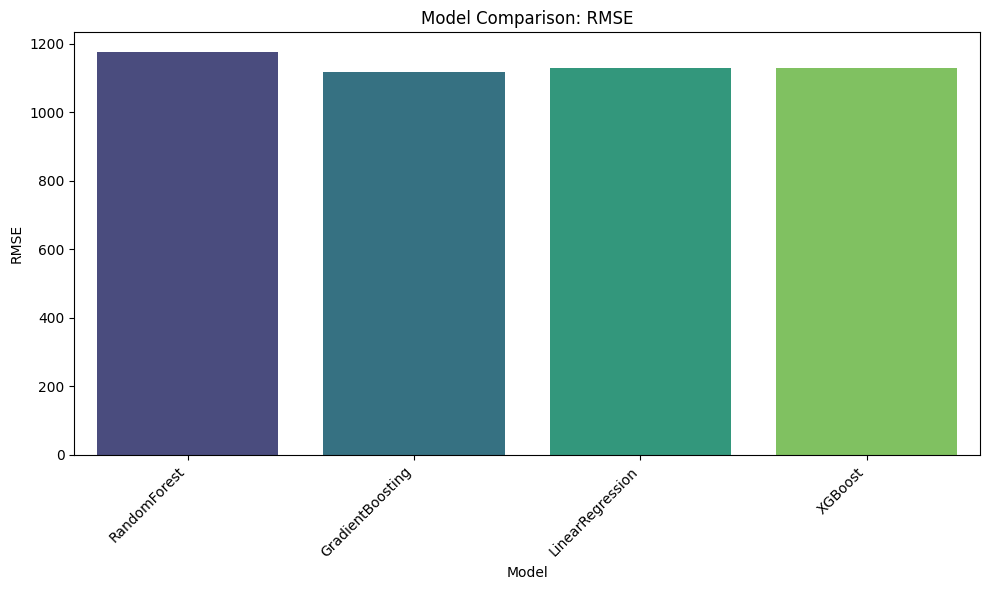

/tmp/ipython-input-761546720.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metrics_df['MAE'], palette='magma')


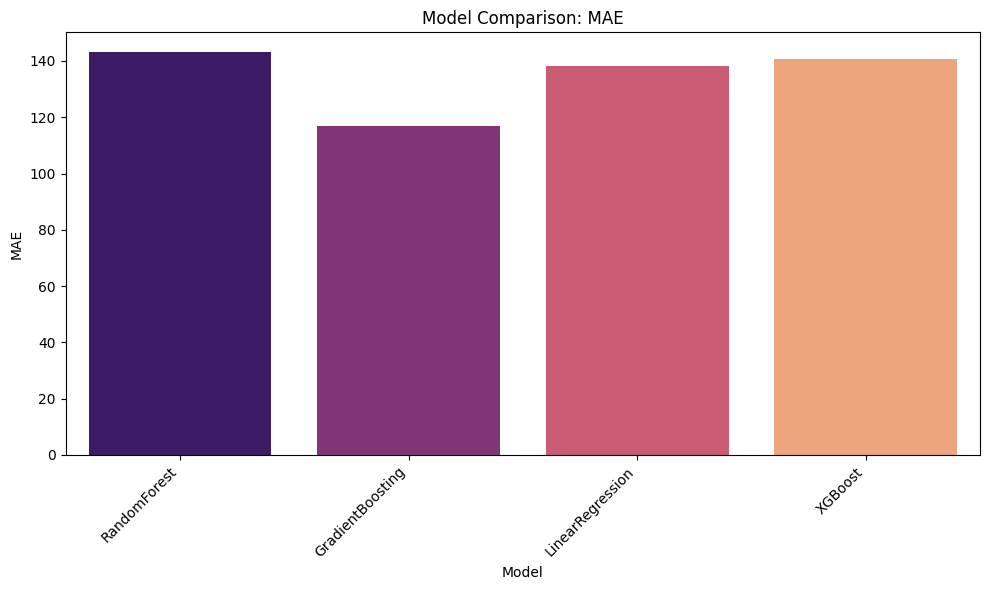

/tmp/ipython-input-761546720.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metrics_df['R2'], palette='plasma')


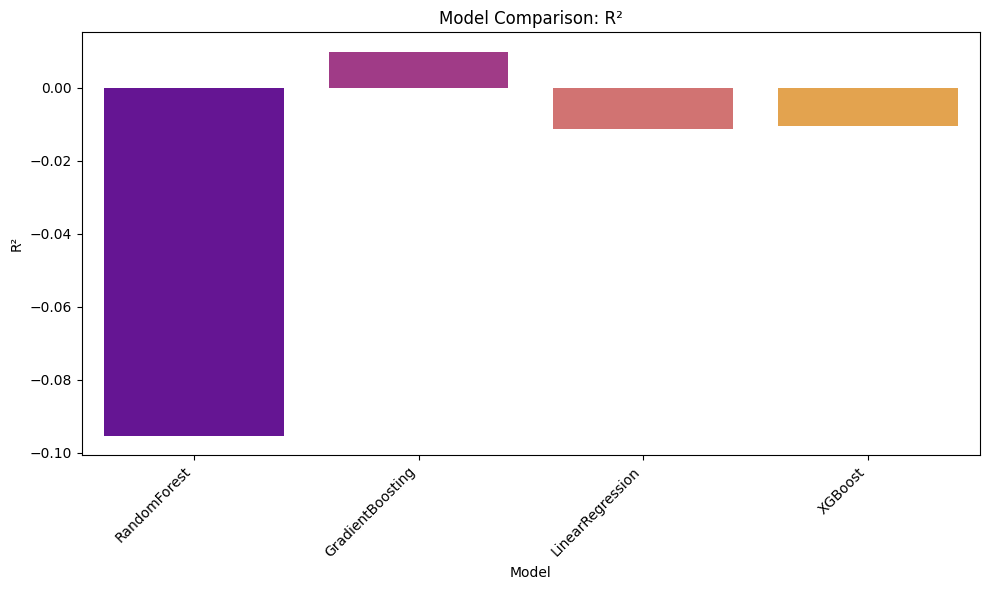

In [59]:
# Create bar charts for each metric to compare models

# RMSE Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=metrics_df.index, y=metrics_df['RMSE'], palette='viridis')
plt.title('Model Comparison: RMSE')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# MAE Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=metrics_df.index, y=metrics_df['MAE'], palette='magma')
plt.title('Model Comparison: MAE')
plt.xlabel('Model')
plt.ylabel('MAE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# R2 Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=metrics_df.index, y=metrics_df['R2'], palette='plasma')
plt.title('Model Comparison: R²')
plt.xlabel('Model')
plt.ylabel('R²')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [60]:
print("Model Performance Comparison:")
display(metrics_df)

print("\nAnalysis:")
print("Based on the performance metrics:")

# Compare RMSE and MAE (lower is better)
best_rmse_model = metrics_df['RMSE'].idxmin()
best_mae_model = metrics_df['MAE'].idxmin()

print(f"- The model with the lowest RMSE is: {best_rmse_model} ({metrics_df['RMSE'].min():.2f})")
print(f"- The model with the lowest MAE is: {best_mae_model} ({metrics_df['MAE'].min():.2f})")

# Compare R² (higher is better)
best_r2_model = metrics_df['R2'].idxmax()
print(f"- The model with the highest R² is: {best_r2_model} ({metrics_df['R2'].max():.3f})")

print("\nDiscussion on Performance:")
print(f"GradientBoosting achieved the lowest RMSE (${metrics_df['RMSE'].min():.2f}) and MAE (${metrics_df['MAE'].min():.2f}), indicating that on average, its predictions have the smallest error magnitude compared to the other models.")
print(f"LinearRegression has the highest R² value ({metrics_df['R2'].max():.3f}), although this value is very close to zero.")
print("All models exhibit R² values close to zero or negative. A negative R² value (like for RandomForest and XGBoost) suggests that the model performs worse than a simple model that just predicts the mean of the target variable.")
print("The very low or negative R² values for all models indicate that none of the models were able to explain a significant portion of the variance in 'Closed PnL'. This suggests that predicting individual trade profitability with the current features and models is challenging.")
print("While GradientBoosting has slightly better error metrics (RMSE, MAE), the R² values across all models highlight that none of them are effective predictors of 'Closed PnL' in this context.")

Model Performance Comparison:


,RMSE,MAE,R2
RandomForest,1174.828587,143.034283,-0.095309
GradientBoosting,1116.964066,117.003535,0.009930
LinearRegression,1128.888752,138.085291,-0.011323
XGBoost,1128.350702,140.601523,-0.010359



Analysis:
Based on the performance metrics:
- The model with the lowest RMSE is: GradientBoosting (1116.96)
- The model with the lowest MAE is: GradientBoosting (117.00)
- The model with the highest R² is: GradientBoosting (0.010)

Discussion on Performance:
GradientBoosting achieved the lowest RMSE ($1116.96) and MAE ($117.00), indicating that on average, its predictions have the smallest error magnitude compared to the other models.
LinearRegression has the highest R² value (0.010), although this value is very close to zero.
All models exhibit R² values close to zero or negative. A negative R² value (like for RandomForest and XGBoost) suggests that the model performs worse than a simple model that just predicts the mean of the target variable.
The very low or negative R² values for all models indicate that none of the models were able to explain a significant portion of the variance in 'Closed PnL'. This suggests that predicting individual trade profitability with the current featur

## Summary:

### Data Analysis Key Findings

*   GradientBoosting achieved the lowest RMSE (\$1116.96) and MAE (\$117.00) among the models evaluated (RandomForest, GradientBoosting, LinearRegression, and XGBoost).
*   GradientBoosting also had the highest R² value (0.010), although this value is very close to zero.
*   RandomForest and XGBoost models resulted in negative R² values, indicating that they performed worse than a simple model predicting the mean of the target variable.
*   None of the models effectively explained a significant portion of the variance in the 'Closed PnL' variable, as evidenced by the R² values being close to zero or negative across all models.

### Insights or Next Steps

*   The current set of features and models are not effective in predicting 'Closed PnL'. Further feature engineering, exploring more complex model architectures, or investigating external factors influencing trade profitability might be necessary.
